In [1]:
from ddsp.audio_feature_dataset import AudioFeatureDataset

dataset_path = '/mnt/mariadata/datasets/noise-artists/hecker/processed'

sampling_rate = 16000
n_dur = 2 # s
n_signal = sampling_rate * n_dur

dataset = AudioFeatureDataset(
  dataset_path=dataset_path,
  sampling_rate=sampling_rate,
  n_signal=n_signal
)

Creating new cache: /mnt/mariadata/datasets/noise-artists/hecker/audio_cache_77918aca.lmdb


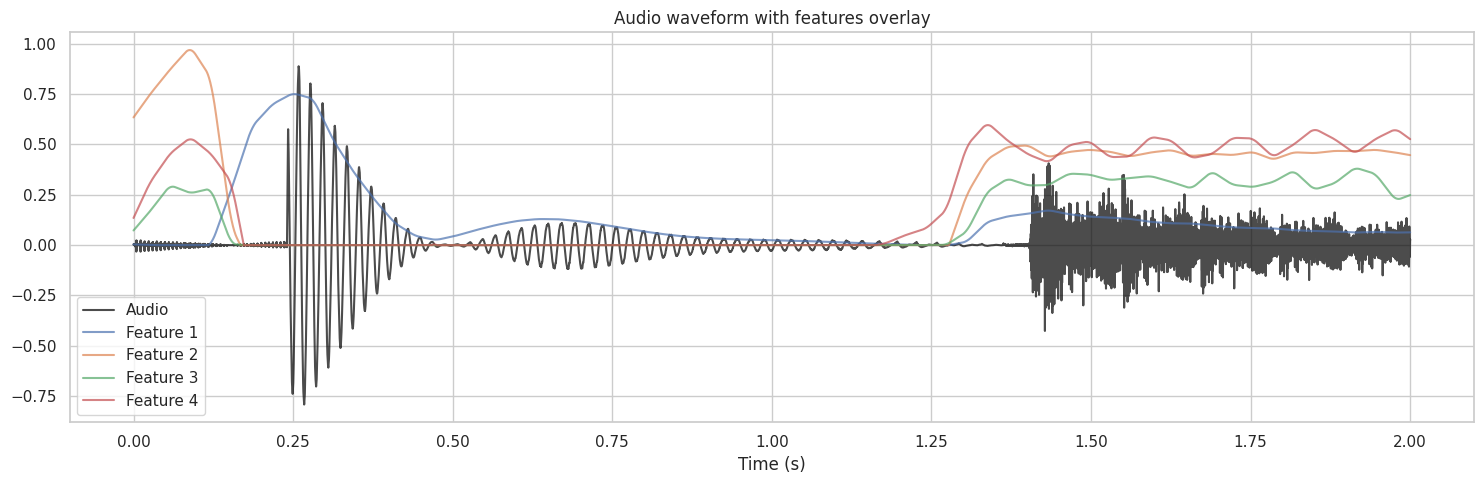

In [4]:
# plot

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from IPython.display import display, Audio

sns.set_theme(style="whitegrid")

idx = random.randint(0, len(dataset) - 1)
audio, features = dataset[idx]

# Plot audio along with features (over the waveform)
audio_np = audio.cpu().numpy()
features_np = features.cpu().numpy()

time = np.linspace(0, n_dur, n_signal)

plt.figure(figsize=(15, 5))
plt.plot(time, audio_np, label='Audio', color='black', alpha=0.7)

for i in range(features_np.shape[1]):
  plt.plot(time, features_np[:, i], label=f'Feature {i+1}', alpha=0.7)

plt.xlabel('Time (s)')
plt.legend()
plt.title('Audio waveform with features overlay')
plt.tight_layout()
plt.show()

display(Audio(audio_np, rate=sampling_rate))